In [1]:
import numpy as np
from pylab import plt, mpl

In [2]:
import seaborn as sns
sns.set_theme(style="darkgrid")
mpl.rcParams['font.family'] = 'serif'
%matplotlib inline

In [3]:
def f(x):
    return np.sin(x) + 0.5 * x

In [4]:
def create_plot(x, y, styles, labels, axlabels):
    plt.figure(figsize=(10,6))
    for i in range(len(x)):
        plt.plot(x[i], y[i], styles[i], label=labels[i])
        plt.xlabel(axlabels[0])
        plt.ylabel(axlabels[1])
    plt.legend(loc=0)

In [5]:
x = np.linspace(-2 * np.pi, 2* np.pi, 50)

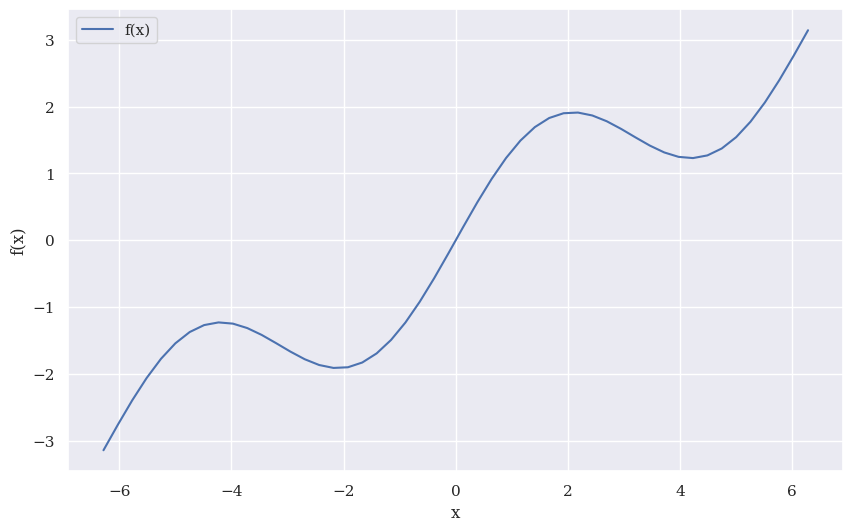

In [6]:
create_plot([x], [f(x)], ['b'], ['f(x)'], ['x','f(x)'])
plt.show()

<span style='font-size:17px'><b>Approximation: Mathematical Foundations</b>

* <b>Functional Form:</b> We define $f(x) = \sin(x) + 0.5x$, representing a function that combines a cyclical component (the sine wave) with a deterministic trend-a structure frequently used to model seasonal finance data.
* <b>Numberical Domain:</b> Using 'np.linspace', we generate a discrete set of 50 values over the interval $[-2\pi, 2\pi]$ to transform the continuous mathematical function into a coordinate-based format for Python processing.
* <b>Visualization Framework:</b> The 'create_plot' function provides a modular way to handle data series, allowing for easy visual comparison between the original 'target' function and the upcoming regression model.

In [7]:
res = np.polyfit(x, f(x), deg=1, full=True)

In [8]:
res

(array([ 4.28841952e-01, -1.40254456e-16]),
 array([21.03238686]),
 np.int32(2),
 array([1., 1.]),
 np.float64(1.1102230246251565e-14))

In [9]:
ry = np.polyval(res[0],x)

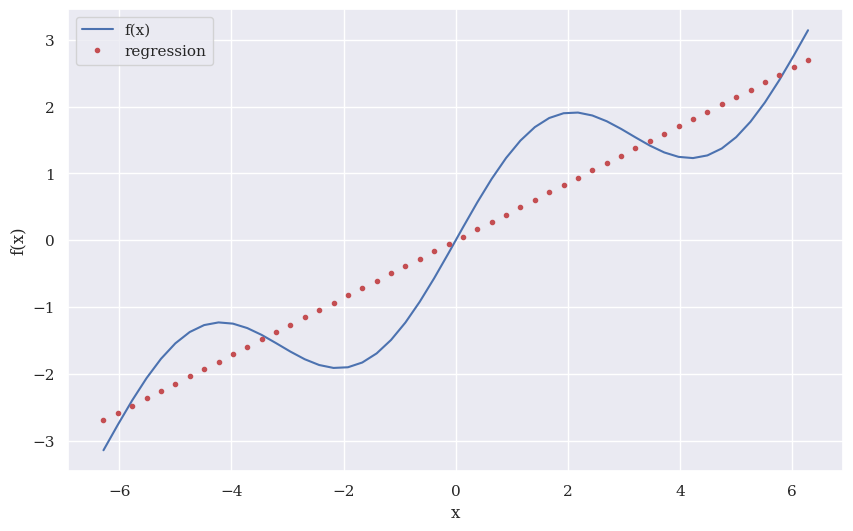

In [10]:
create_plot([x,x], [f(x), ry], ['b', 'r.'],
            ['f(x)','regression'], ['x','f(x)'])
plt.show()

In [11]:
reg = np.polyfit(x, f(x), deg=5)
ry = np.polyval(reg, x)

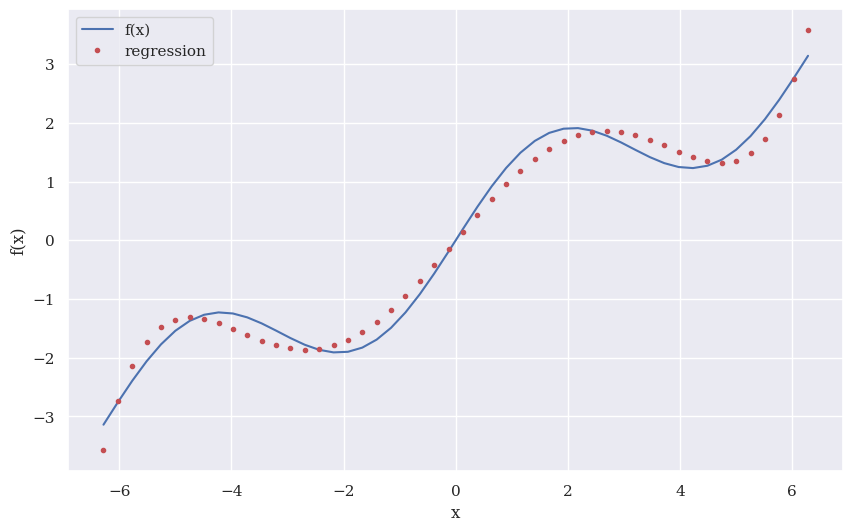

In [12]:
create_plot([x,x], [f(x), ry], ['b', 'r.'],
            ['f(x)','regression'], ['x','f(x)'])
plt.show()

In [13]:
reg = np.polyfit(x, f(x), deg=7)
ry = np.polyval(reg, x)

In [14]:
np.allclose(f(x), ry)

False

In [15]:
np.mean((f(x) - ry) ** 2)

np.float64(0.0017769134759517593)

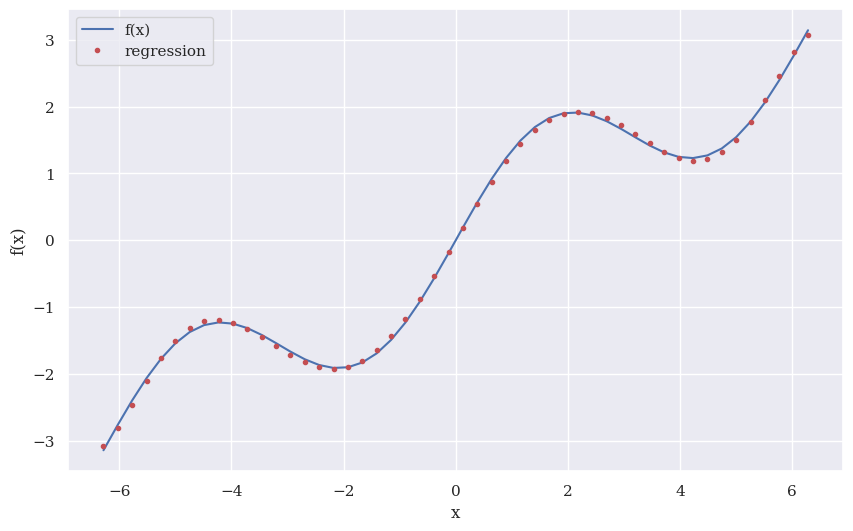

In [16]:
create_plot([x,x], [f(x), ry], ['b', 'r.'],
            ['f(x)','regression'], ['x','f(x)'])
plt.show()

<span style='font-size:17px'><b>Regression: From Linear to Polynomial Fits</b>

* <b>Degree 1 (Linear):</b> A first-degree polynomial (a straight-line) captures the general upward trend of $f(x)$ but fails to account the cyclical sine wave, resulting in a high 'residual' error.
* <b>Degree 5 & 7 (Polynomial):</b> By increasing the degree, we introduce more basis functions ($x^2, x^3, ...$). A degree-7 polynomial provides a much tighter fit, successfully tracing the curves of the sine wave while maintaining the overall linear trend.
* <b>Error Measurement:</b>We use 'np.mean((f(x) - ry) ** 2)' to calculate the **Mean Squared Error (MSE)**. As the degree increases, this value decreases, quantifying the improvement in our approximation's accuracy.
* <b>Numerical Validation:</b> 'np.allclose()' checks if the original data and the regression are identical within a small tolerance. Even with a degree-7 fit, it returns 'False', reminding us that a polynomial is an <i>approximation</i>, not an exact replication of a transcendental function like $\sin(x)$.

In [17]:
matrix = np.zeros((3 + 1, len(x)))
matrix[3, :] = x ** 3
matrix[2, :] = x ** 2
matrix[1, :] = x
matrix[0, :] = 1

In [18]:
reg = np.linalg.lstsq(matrix.T, f(x), rcond=None)[0]

In [19]:
reg.round(4)

array([ 0.    ,  0.5628, -0.    , -0.0054])

In [20]:
ry = np.dot(reg, matrix)

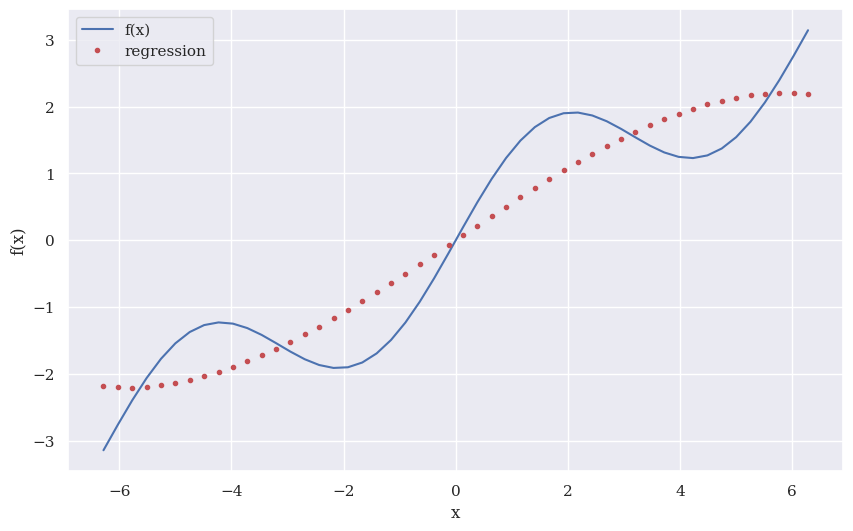

In [21]:
create_plot([x,x], [f(x), ry], ['b', 'r.'],
            ['f(x)','regression'], ['x','f(x)'])
plt.show()

In [22]:
matrix[3, :] = np.sin(x)

In [23]:
reg = np.linalg.lstsq(matrix.T, f(x), rcond=None)[0]

In [24]:
reg.round(4)

array([0. , 0.5, 0. , 1. ])

In [25]:
ry = np.dot(reg, matrix)

In [26]:
np.allclose(f(x), ry)

True

In [27]:
np.mean((f(x) - ry) ** 2)

np.float64(3.345571424993955e-31)

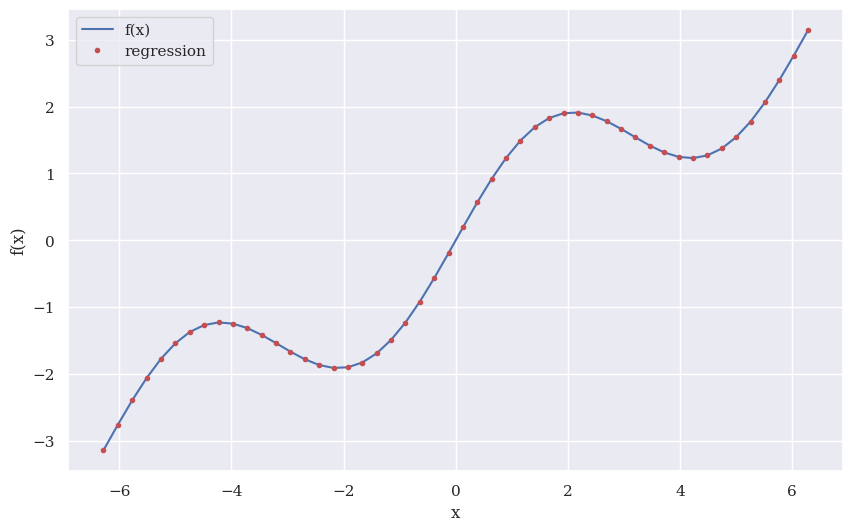

In [28]:
create_plot([x,x], [f(x), ry], ['b', 'r.'],
            ['f(x)','regression'], ['x','f(x)'])
plt.show()

<span style='font-size:17px'><b>Generalizing Basis Functions with Least-Squares</b>

* <b>Beyond Polynomials:</b> While polynomials are versatile, they aren't always the most efficient building blocks. By manually constructing a **Basis Matrix**, we can choose functions that match the known characteristics of our target data (like seasonality or oscillation).
* <b>The 'Perfect' Basis:</b> In the first plot, we use $[1, x, x^2, x^3]$. In the second, we swapped $x^3$ for $\sin(x)$. Because our original function $f(x)$ was built using a sine wave, the regression immediately found a near-perfect fit.
* <b>Numerical Precision:</b> Notice the 'np.allclose()' result is now 'True' and the Mean Squared Error (MSE) has dropped to nearly ($3.34 \times 10^{-31}$). This indicates that our model is no longer just approximating-it has successfully recovered the underlying mathematical structure.
* <b>Optimal Parameters ($\beta$):</b> The reg.round(4)' output of '[0, 0.5, 0, 1]' corresponds exactly to our function $f(x) = 0.5x + 1\sin(x)$, proving that the least-squares solver ('np.linalg.lstsq') correctly identified the original coefficients.

In [29]:
xn = np.linspace(-2 * np.pi, 2 * np.pi, 50)
xn = xn + 0.15 * np.random.standard_normal(len(xn))
yn = f(xn) + 0.25 * np.random.standard_normal(len(xn))

In [30]:
reg = np.polyfit(xn, yn, 7)
ry = np.polyval(reg, xn)

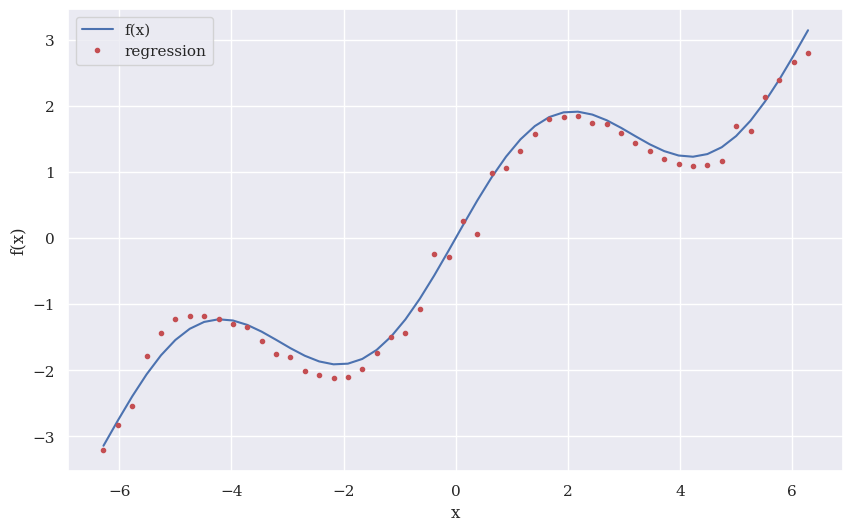

In [31]:
create_plot([x,x], [f(x), ry], ['b', 'r.'],
            ['f(x)','regression'], ['x','f(x)'])
plt.show()

In [32]:
xu = np.random.rand(50) * 4 * np.pi - 2 * np.pi
yu = f(xu)

In [33]:
print(xu[:10].round(2))
print(yu[:10].round(2))

[1.83 6.12 3.21 4.04 5.05 6.22 5.97 4.66 2.67 3.19]
[1.88 2.9  1.54 1.24 1.58 3.04 2.67 1.33 1.79 1.55]


In [34]:
reg = np.polyfit(xu, yu, 5)
ry = np.polyval(reg, xu)

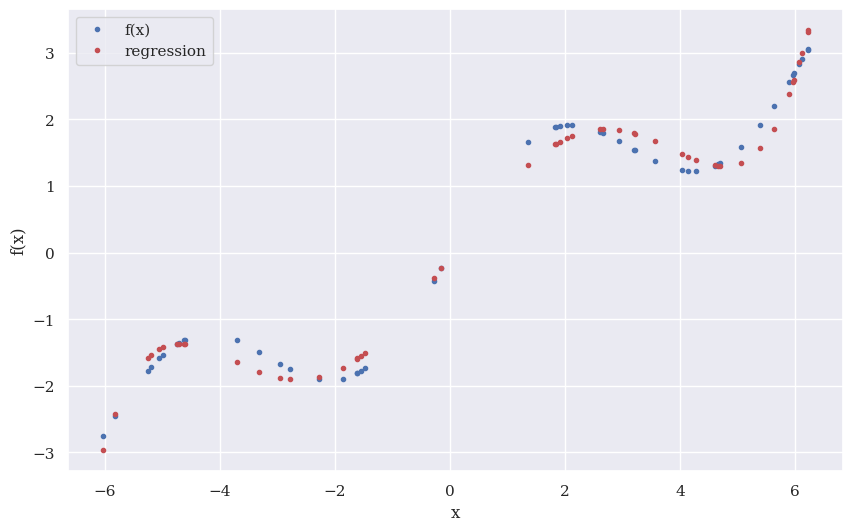

In [35]:
create_plot([xu, xu], [yu, ry], ['b.', 'r.'],
            ['f(x)','regression'], ['x','f(x)'])
plt.show()

<span style='font-size:17px'><b>Regression with Noisy and Unsorted (Stochastic) Data</b>

* <b>Handling Noisy Inputs:</b> In the first plot, we introduced Gaussian noise to both the $x$ and $y$ values using 'np.random.standard_normal'. Despite these 'imperfect'measurements, the 7th-degree regression successfully captures the underlying sine-wave trend, effectively filtering out the noise.
* <b>Stochastic (Unsorted) Sampling:</b> The second plot uses 'np.random.rand' to generate $x$ values in a completely random order. This simulates real-world data collection where observations don't arrive in a neat, sequential timeline.
* <b>Algorithmic Invariance:</b> These examples demonstrate that the least-squares regression algorithm is 'order-independent.' It calculates the optimal $\beta$ parameters based on the coordinates themselves, regardless of whether the array is sorted or jumbled.
* <b>Visual Representation:</b> To avoid 'criss-crossing' lines in the visualization, we switch the plot style to dots ('b.' and 'r.'). This allows us to see how closely the regression points (red) shadow the original function points (blue) across the entire domain.
  

In [36]:
def fm(p):
    x, y = p
    return np.sin(X) + 0.25 * X + np.sqrt(Y) + 0.05 * Y ** 2 

In [37]:
x = np.linspace(0, 10, 20)
y = np.linspace(0, 10, 20)
X, Y = np.meshgrid(x, y)

In [38]:
Z = np.sin(X) + 0.25 * X + np.sqrt(Y) + 0.05 * Y ** 2 

In [39]:
from mpl_toolkits.mplot3d import Axes3D

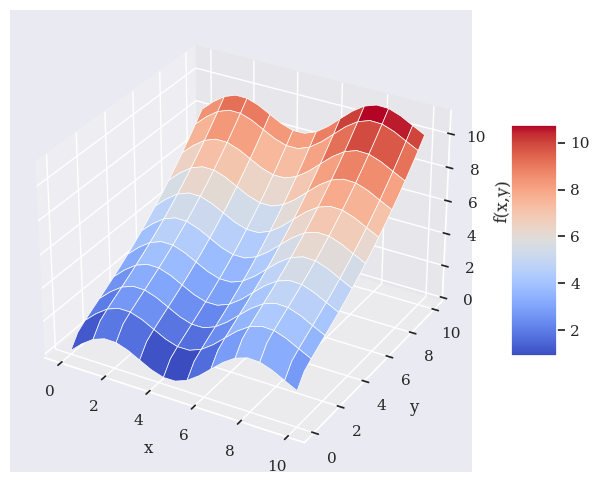

In [42]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(x, Y, Z, rstride=2, cstride=2, 
                       cmap='coolwarm', linewidth=0.5,
                       antialiased=True)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

In [44]:
matrix = np.zeros((len(x), 6 + 1))
matrix[:, 6] = np.sqrt(y)
matrix[:, 5] = np.sin(x)
matrix[:, 4] = y ** 2
matrix[:, 3] = x ** 2
matrix[:, 2] = y
matrix[:, 1] = x
matrix[:, 0] = 1

In [45]:
reg = np.linalg.lstsq(matrix, fm((x,y)), rcond=None)[0]

In [46]:
RZ = np.dot(matrix, reg).reshape((20,20))

C:\Users\wyatt\AppData\Local\Temp\ipykernel_32756\431219123.py:11: UserWarning: Adding colorbar to a different Figure <Figure size 1000x600 with 5 Axes> than <Figure size 1000x800 with 1 Axes> which fig.colorbar is called on.
  fig.colorbar(surf, shrink=0.5, aspect=5)


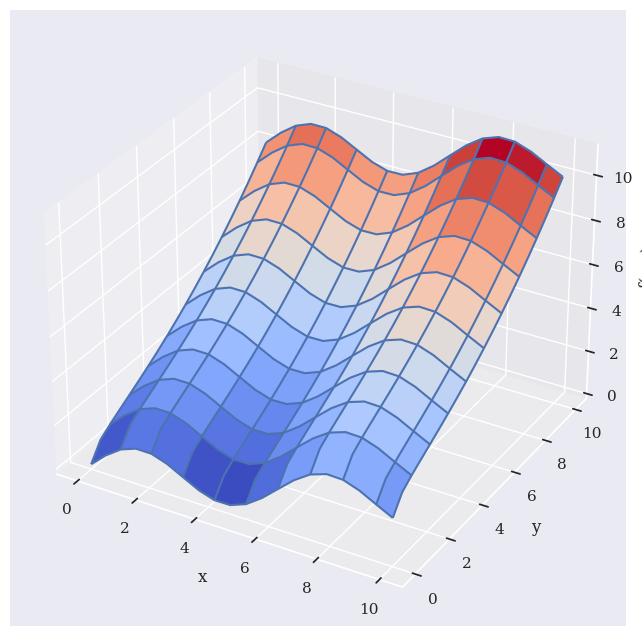

In [51]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
surf1 = ax.plot_surface(x, Y, Z, rstride=2, cstride=2, 
                       cmap='coolwarm', linewidth=0.5,
                       antialiased=True)
surf2 = ax.plot_wireframe(x, Y, RZ, rstride = 2, cstride=2,
                          label='regression')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

<span style='font-size:17px'><b>3D Function Approximation: Surface Fitting</b>

* <b>Complex Basic Sets:</b> To fit a 3D surface, we expand our basic function to include terms for both $x$ and $y$. In cell [44], we used a combination of powers ($x^2, y^2$), a sine wave ($\sin(x)$), and a square root ($\sqrt{y}$) to build the model.
* <b>The 'Wireframe' Test:</b> By plotting the regression result as a 'plot_wireframe' over the original 'plot_surface', we can visually verify the accuracy of the fit. If the grid lines 'hug' the colored surface, the model has captured the data's geometry.
* <b>Matrix Flattening:</b> Notice that the regression math happens in 1D space (flattened), but the results are 'reshape((20,20))' back into a grid. This is the 'secret sauce' for moving between the solver and the 3D plot.
* <b>Parameter Recovery:</b> The solver ('np.linalg.ltstq') effectively finds the weight of ($\beta$) for each component (sin, sqrt, etc.), proving that even in 3D, the least-squares approach is incredibly robust.

In [53]:
import scipy.interpolate as spi

In [54]:
x = np.linspace(-2 * np.pi, 25)

In [55]:
def f(x):
    return np.sin(x) + 0.5 * x

In [56]:
ipo = spi.splrep(x, f(x), k = 1)

In [57]:
iy = spi.splev(x, ipo)

In [58]:
np.allclose(f(x), iy)

True

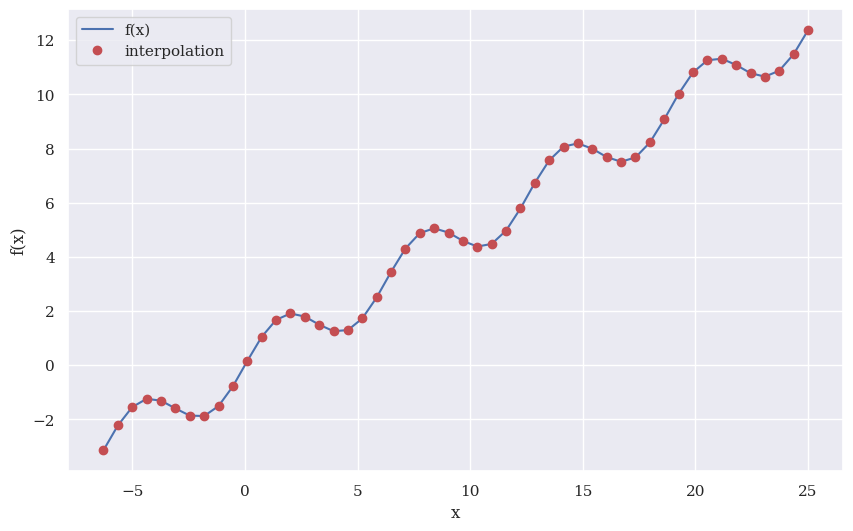

In [61]:
create_plot([x,x], [f(x), iy], ['b', 'ro'],
            ['f(x)', 'interpolation'], ['x', 'f(x)'])
plt.show()

In [62]:
xd = np.linspace(1.0, 3.0, 50)
iyd = spi.splev(xd, ipo)

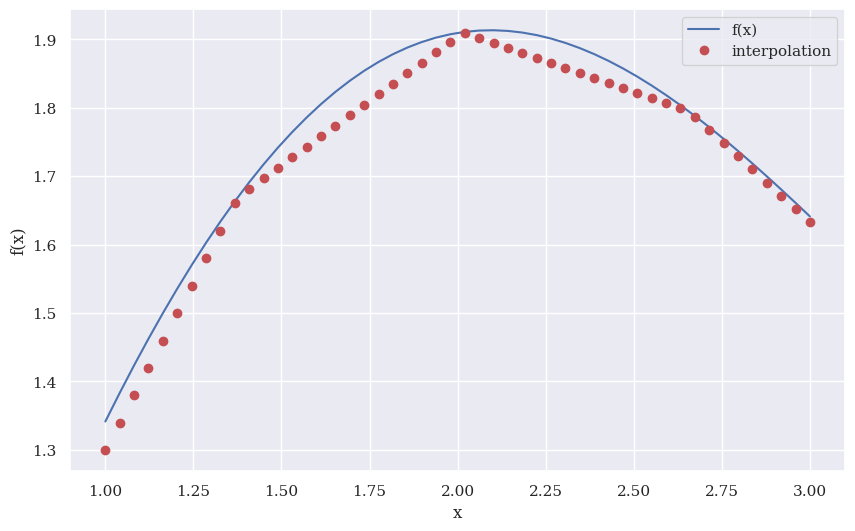

In [64]:
create_plot([xd,xd], [f(xd), iyd], ['b', 'ro'],
            ['f(x)', 'interpolation'], ['x', 'f(x)'])
plt.show()

In [65]:
ipo = spi.splrep(x, f(x), k=3)
iyd = spi.splev(xd, ipo)

In [66]:
np.allclose(f(xd), iyd)

False

In [67]:
np.mean((f(xd) - iyd) ** 2)

np.float64(6.226806740032711e-08)

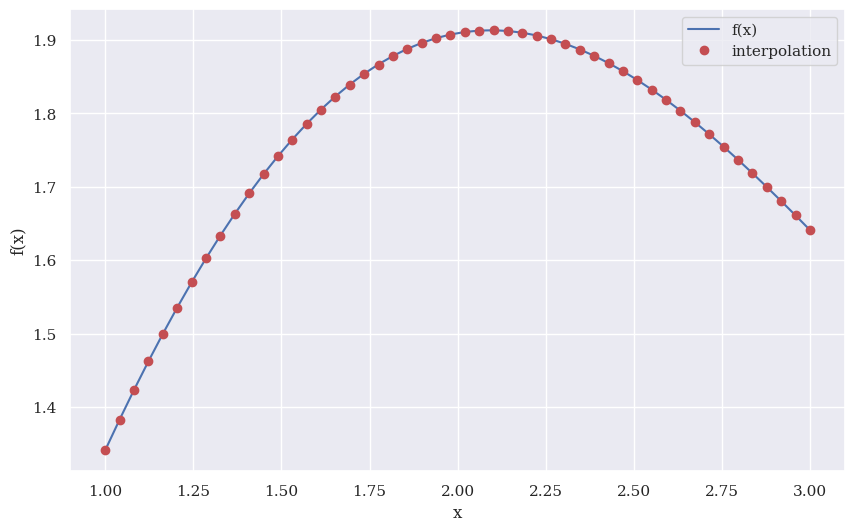

In [68]:
create_plot([xd,xd], [f(xd), iyd], ['b', 'ro'],
            ['f(x)', 'interpolation'], ['x', 'f(x)'])
plt.show()

<span style='font-size:17px'><b>Spline Interpolation: Exact Point Matching</b>

* <b>Regression vs. Interpolation:</b> Unlike regression, which minimizes global error but may not hit any specific point, interpolation creates a 'piece-wise' function that is forced to pass exactly through every provided data point.
* <b>Linear Splines ($k=1$):</b> This method connects points with straight lines. As seen in the zoomed-in plot, this creates a 'connect-the-dots' effect with sharp angles (kinks) at the data points, which often fails to capture the smooth curvature of the underlying function.
* <b>Cubic Splines ($k=3$):</b> This is the gold standard for smoothness. It uses third-degree polynomials to ensure that the 'slope' and 'curvature' match perfectly at every junction, resulting in a seamless curve that effectively recovers the orginal function.
* <b>The Interpolation Workflow:</b> The process involves first calculating a mathematical representation (the coefficients) of the segments and then evaluating that representation over a denser interval to produce a high-resolution curve.
* <b>Differentiability:</b> A key advantage of cubic splines is that they are 'continuously differentiable.' In plain english, this means that there are no sudden jumps or sharp corners, making them ideal for modeling financial variables like interest rate curves.